# Data Analysis

In this analysis phase, we will focus on computing the following key metrics for each product:

### 1. Volume (Sales Count)
- Defined as the **number of purchase events** associated with a product ID.
- Since there is no quantity column, each row represents a single purchase event.
- Multiple purchases of the same product by the same user appear as multiple rows.
- **Calculation:** count of purchase-event rows per product.

---

### 2. Revenue (Gross Income)
- Defined as the **sum of the price column** for purchase events.
- No data is available for shipping costs, wholesale costs, or taxes.
- This metric therefore represents **gross revenue**, not profit.
- **Calculation:** sum of prices per product.

---

### 3. Popularity (Unique Buyers)
- Defined as the **number of unique users** who purchased a product.
- Repeated purchases by the same user are counted once.
- Serves as a proxy for product popularity rather than purchase intensity.
- **Calculation:** count of distinct user IDs per product.

---

### 4. Change in Performance (Temporal Comparison)
- Measures how product performance evolves over time.
- Metrics are calculated **separately for November and December**.
- Enables comparison of volume, revenue, and popularity between the two periods.
- **Calculation:** per-metric comparison across months.

---

### 5. Conversion Rate
- Defined as the **percentage of cart events that result in a purchase**.
- Reflects how effectively cart additions convert into completed purchases.
- Product views are not considered due to missing data.
- **Calculation:**  
$$
\text{Conversion Rate} =
\frac{\text{Number of purchase events}}
{\text{Number of cart events}} \times 100
$$

---

These metrics together provide a structured view of **sales performance, customer reach, temporal trends, and conversion efficiency** in the absence of detailed quantity or browsing data.


In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the cleaned data
events = pd.read_parquet('./datasets/events.parquet.gz')

In [3]:
events.head()

,event_time,event_type,product_id,brand,subcategory,category_id,category,user_id,user_session,product_identifier,price
0,2019-11-01 00:00:14+00:00,cart,1005014,samsung,electronics.smartphone,2053013555631882655,electronics,533326659,6b928be2-2bce-4640-8296-0efdf2fda22a,1005014-samsung electronics.smartphone,503.09
1,2019-11-01 00:00:41+00:00,purchase,13200605,NaN,furniture.bedroom.bed,2053013557192163841,furniture,559368633,d6034fa2-41fb-4ac0-9051-55ea9fc9147a,NaN,566.30
2,2019-11-01 00:01:04+00:00,purchase,1005161,xiaomi,electronics.smartphone,2053013555631882655,electronics,513351129,e6b7ce9b-1938-4e20-976c-8b4163aea11d,1005161-xiaomi electronics.smartphone,211.92
3,2019-11-01 00:03:24+00:00,cart,1801881,samsung,appliances.personal.massager,2053013554415534427,appliances,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e,1801881-samsung appliances.personal.massager,488.80
4,2019-11-01 00:03:39+00:00,cart,1005115,apple,electronics.smartphone,2053013555631882655,electronics,565865924,fd4bd6d4-bd14-4fdc-9aff-bd41a594f82e,1005115-apple electronics.smartphone,949.47


In [4]:
# Make a copy to separate purchase and cart events
purchases = events[events.event_type == 'purchase'].copy()
carts = events[events.event_type == 'cart'].copy()

In [5]:
# Creating month-specific columns for November and December

purchases.assign(
    november_count=np.where(purchases['event_time'].dt.month == 11, 1, 0),
    november_revenue=np.where(purchases['event_time'].dt.month == 11, purchases['price'], 0),
    november_user_id =np.where(purchases['event_time'].dt.month == 11, purchases['user_id'], None),
    december_count=np.where(purchases['event_time'].dt.month == 12, 1, 0),
    december_revenue=np.where(purchases['event_time'].dt.month == 12, purchases['price'], 0),
    december_user_id =np.where(purchases['event_time'].dt.month == 12, purchases['user_id'], None)
)

,event_time,event_type,product_id,brand,subcategory,category_id,category,user_id,user_session,product_identifier,price,november_count,november_revenue,november_user_id,december_count,december_revenue,december_user_id
1,2019-11-01 00:00:41+00:00,purchase,13200605,NaN,furniture.bedroom.bed,2053013557192163841,furniture,559368633,d6034fa2-41fb-4ac0-9051-55ea9fc9147a,NaN,566.30,1,566.30,559368633,0,0.00,None
2,2019-11-01 00:01:04+00:00,purchase,1005161,xiaomi,electronics.smartphone,2053013555631882655,electronics,513351129,e6b7ce9b-1938-4e20-976c-8b4163aea11d,1005161-xiaomi electronics.smartphone,211.92,1,211.92,513351129,0,0.00,None
5,2019-11-01 00:04:51+00:00,purchase,1004856,samsung,electronics.smartphone,2053013555631882655,electronics,562958505,0f039697-fedc-40fa-8830-39c1a024351d,1004856-samsung electronics.smartphone,128.42,1,128.42,562958505,0,0.00,None
7,2019-11-01 00:06:33+00:00,purchase,1801881,samsung,appliances.personal.massager,2053013554415534427,appliances,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e,1801881-samsung appliances.personal.massager,488.80,1,488.80,557746614,0,0.00,None
8,2019-11-01 00:06:34+00:00,purchase,5800823,nakamichi,electronics.audio.subwoofer,2053013553945772349,electronics,514166940,8ef5214a-86ad-4d0b-8df3-4280dd411b47,5800823-nakamichi electronics.audio.subwoofer,123.56,1,123.56,514166940,0,0.00,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023545,2019-12-31 17:01:33+00:00,purchase,1005105,apple,electronics.smartphone,2232732093077520756,electronics,558444704,ca84a221-d0f7-4e5b-a01a-704fe4059b40,1005105-apple electronics.smartphone,1275.81,0,0.00,None,1,1275.81,558444704
7023551,2019-12-31 17:01:36+00:00,purchase,4804055,apple,sport.bicycle,2232732079706079299,sport,572536740,89528571-8c10-4989-8efc-78e2c8590136,4804055-apple sport.bicycle,197.28,0,0.00,None,1,197.28,572536740
7023556,2019-12-31 17:01:38+00:00,purchase,1005126,apple,electronics.smartphone,2232732093077520756,electronics,514945482,1714bc55-8528-4936-a678-c8385905e096,1005126-apple electronics.smartphone,1266.94,0,0.00,None,1,1266.94,514945482
7023557,2019-12-31 17:01:38+00:00,purchase,5100816,xiaomi,apparel.shoes,2232732103831716449,apparel,559909071,d0c877f1-fb93-4f6e-9ecc-5b7d124b08ba,5100816-xiaomi apparel.shoes,29.95,0,0.00,None,1,29.95,559909071


In [6]:
# Temporary table for purchases

purchases_table = (
    purchases
    .assign(
        november_count=np.where(purchases['event_time'].dt.month == 11, 1, 0),
        november_revenue=np.where(purchases['event_time'].dt.month == 11, purchases['price'], 0),
        november_user_id =np.where(purchases['event_time'].dt.month == 11, purchases['user_id'], None),
        december_count=np.where(purchases['event_time'].dt.month == 12, 1, 0),
        december_revenue=np.where(purchases['event_time'].dt.month == 12, purchases['price'], 0),
        december_user_id =np.where(purchases['event_time'].dt.month == 12, purchases['user_id'], None),
    )
.groupby(['product_id', 'product_identifier'])\
.agg(
    november_volume = ('november_count', 'sum'),
    november_revenue = ('november_revenue', 'sum'),
    november_users = ('november_user_id', 'nunique'),
    december_volume = ('december_count', 'sum'),
    december_revenue = ('december_revenue', 'sum'),
    december_users = ('december_user_id', 'nunique')
)
    .assign(
        volume_diff = lambda x: x['december_volume'] - x['november_volume'],
        revenue_diff = lambda x: x['december_revenue'] - x['november_revenue'],
        user_diff = lambda x: x['december_users'] - x['november_users']
    ) .reset_index()
)

purchases_table.head()

,product_id,product_identifier,november_volume,november_revenue,november_users,december_volume,december_revenue,december_users,volume_diff,revenue_diff,user_diff
0,1000978,1000978-samsung electronics.smartphone,20,6135.32,17,16,4260.40,16,-4,-1874.92,-1
1,1001588,1001588-meizu electronics.smartphone,6,766.29,5,13,1652.55,12,7,886.26,7
2,1001605,1001605-apple electronics.smartphone,0,0.00,0,18,9806.76,16,18,9806.76,16
3,1001606,1001606-apple electronics.smartphone,0,0.00,0,11,5662.69,10,11,5662.69,10
4,1001618,1001618-apple electronics.smartphone,36,18059.76,25,7,4745.84,7,-29,-13313.92,-18


In [7]:
purchases_table.shape

(45403, 11)

In [8]:
conversion_table = (
    pd.pivot_table(
        data=events.assign(month=events['event_time'].dt.month),
        index=['product_id', 'product_identifier'],
        columns=['month', 'event_type'],
        values='user_session',
        aggfunc='count',
        fill_value=0
    )
)

conversion_table.columns = [
    f"{'november' if month == 11 else 'december'}_{event}"
    for month, event in conversion_table.columns
]

conversion_table = (
    conversion_table
    .reset_index()
    .assign(
        november_conversion=lambda x: x['november_purchase'] / x['november_cart'],
        december_conversion=lambda x: x['december_purchase'] / x['december_cart']
    )
)

conversion_table

,product_id,product_identifier,november_cart,november_purchase,december_cart,december_purchase,november_conversion,december_conversion
0,1000894,1000894-texet electronics.smartphone,0,0,4,0,NaN,0.000000
1,1000978,1000978-samsung electronics.smartphone,60,20,58,16,0.333333,0.275862
2,1001588,1001588-meizu electronics.smartphone,16,6,37,13,0.375000,0.351351
3,1001605,1001605-apple electronics.smartphone,0,0,42,18,NaN,0.428571
4,1001606,1001606-apple electronics.smartphone,0,0,23,11,NaN,0.478261
...,...,...,...,...,...,...,...,...
66898,100063570,100063570-rastar apparel.scarf,0,0,0,1,NaN,inf
66899,100063691,100063691-turtle apparel.shirt,0,0,1,1,NaN,1.000000
66900,100063815,100063815-rock construction.tools.generator,0,0,1,1,NaN,1.000000
66901,100064136,100064136-turtle apparel.shirt,0,0,2,0,NaN,0.000000


In [9]:
conversion_table.loc[
    np.isinf(conversion_table['november_conversion']) &
    np.isinf(conversion_table['december_conversion'])
]

,product_id,product_identifier,november_cart,november_purchase,december_cart,december_purchase,november_conversion,december_conversion


In [10]:
purchases_table[['product_id', 'product_identifier']].duplicated().sum()

np.int64(0)

In [11]:
conversion_table[['product_id', 'product_identifier']].duplicated().sum()

np.int64(0)

> Some products have 0 carts but at least one purchase, Which is inconsistent and needs attention. For now, since there are nore duplicate keys in either metric tables, we will proceed with a left merge using the purchases table as the base.

In [12]:
# Create metrics table

metrics_table = purchases_table.merge(conversion_table, on=['product_id', 'product_identifier'], how='left')
metrics_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 45403 entries, 0 to 45402
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           45403 non-null  int64  
 1   product_identifier   45403 non-null  str    
 2   november_volume      45403 non-null  int64  
 3   november_revenue     45403 non-null  float64
 4   november_users       45403 non-null  int64  
 5   december_volume      45403 non-null  int64  
 6   december_revenue     45403 non-null  float64
 7   december_users       45403 non-null  int64  
 8   volume_diff          45403 non-null  int64  
 9   revenue_diff         45403 non-null  float64
 10  user_diff            45403 non-null  int64  
 11  november_cart        45403 non-null  int64  
 12  november_purchase    45403 non-null  int64  
 13  december_cart        45403 non-null  int64  
 14  december_purchase    45403 non-null  int64  
 15  november_conversion  24377 non-null  float64
 1

### Finding the best products using our defined metrics

We have multiple options, such as:
- Picking a single metric to sort the league table by and thinking of the top N products as being the best.
- We could weight each metric by its relative importance, create a weighted combination of metric values to come up with a single value to define each product, and use that value to find the top N.
- If we care specifically about December performers, we could look at outliers in our difference metrics, such as the difference in volume between November and December.

There are many more options, but since the brief was specifically about the December sale period, we will focus our efforts on products that showed the biggest month-on-month increases. For which of the metrics should we focus on this difference? Our options are

- Change in revenue —Focusing on absolute revenue might mean expensive items skew our results.
- Change in the number of unique users —This might be a good measure for products that perform better month-on-month.
- Change in volume —This seems like a solid, logical place to start as simply selling more of an item month-on-month is an indicator of good performance.

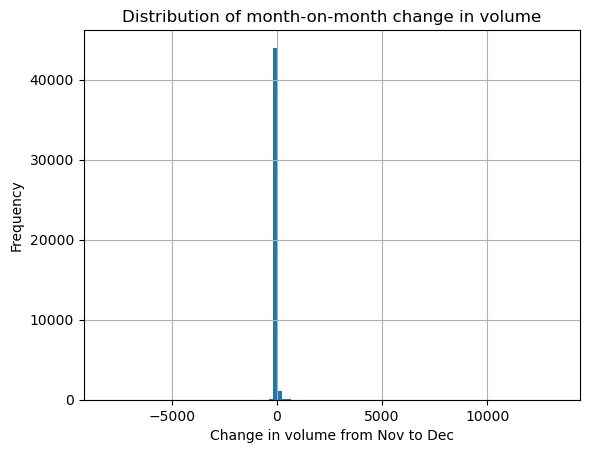

In [13]:
# Visualize the month-on-month change in volume

fig, axis = plt.subplots()
metrics_table['volume_diff'].hist(bins=100, ax=axis)
axis.set(title = 'Distribution of month-on-month change in volume',
         xlabel = 'Change in volume from Nov to Dec',
         ylabel = 'Frequency');

> Clearly, there are outliers that skew this histogram beyond usefulness. 

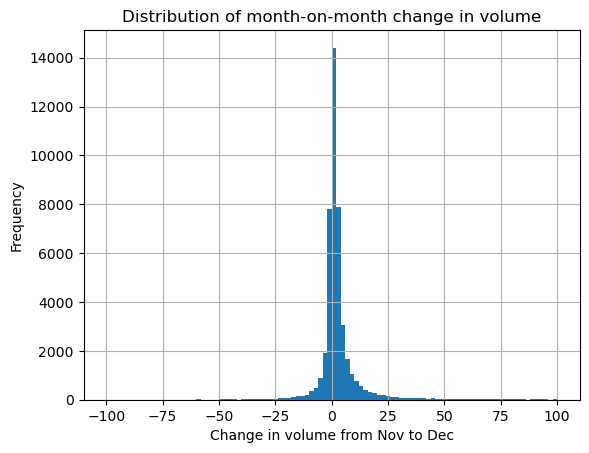

In [14]:
# Let’s zoom into the middle to see if the month-on-month change is centered around zero.

fig, axis = plt.subplots()
metrics_table.loc[metrics_table['volume_diff'].between(-100, 100), 'volume_diff'].hist(bins=100, ax=axis)
axis.set(title = 'Distribution of month-on-month change in volume',
         xlabel = 'Change in volume from Nov to Dec',
         ylabel = 'Frequency');

> Looking at this histogram closely, we see that most products haven't changed much in sales volume month-on-month, and some products solds more, while others sold less.

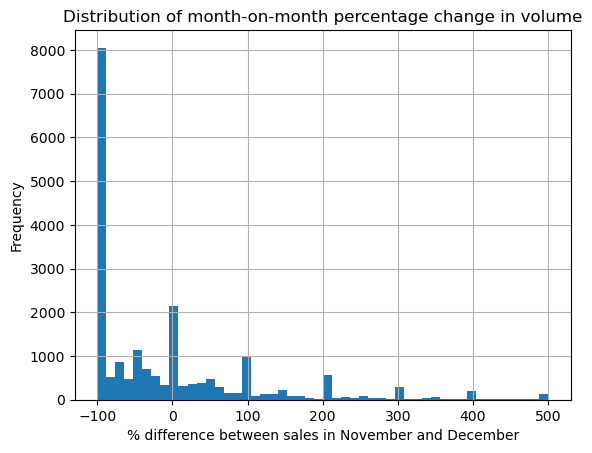

In [15]:
# Visualize it percentage

metrics_table['volume_diff_pct'] = (metrics_table['volume_diff']/metrics_table['november_volume']) * 100

fig, axis = plt.subplots()
(
    metrics_table["volume_diff_pct"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .loc[lambda x: x.between(-101,501)]
    .hist(bins=50, ax=axis)
)

axis.set(
    title="Distribution of month-on-month percentage change in volume",
    xlabel="% difference between sales in November and December",
    ylabel="Frequency"
);

> Most products seem to have actually sold nothing in December versus November since a -100% change means 0 imtens sold in December.

In [16]:
# Create a product catalog for details 

product_catalog = (
    events[['product_id', 'product_identifier', 'category_id', 'subcategory', 'category', 'brand']]
    .drop_duplicates(subset=['product_id', 'product_identifier', 'subcategory', 'category', 'brand'])
)    
    
assert len(product_catalog) == events['product_id'].nunique() #Verif

product_catalog

,product_id,product_identifier,category_id,subcategory,category,brand
0,1005014,1005014-samsung electronics.smartphone,2053013555631882655,electronics.smartphone,electronics,samsung
1,13200605,NaN,2053013557192163841,furniture.bedroom.bed,furniture,NaN
2,1005161,1005161-xiaomi electronics.smartphone,2053013555631882655,electronics.smartphone,electronics,xiaomi
3,1801881,1801881-samsung appliances.personal.massager,2053013554415534427,appliances.personal.massager,appliances,samsung
4,1005115,1005115-apple electronics.smartphone,2053013555631882655,electronics.smartphone,electronics,apple
...,...,...,...,...,...,...
7032524,8902588,8902588-cubicfun computers.desktop,2232732085150286011,computers.desktop,computers,cubicfun
7032557,26601017,26601017-sokolov furniture.bedroom.bed,2232732081895506036,furniture.bedroom.bed,furniture,sokolov
7032624,8901697,8901697-playgro computers.desktop,2232732085150286011,computers.desktop,computers,playgro
7032842,57300015,NaN,2232732129735737558,sport.ski,sport,NaN


In [17]:
# Merging the metrics and details based on the defined thresholds

DEC_VS_NOV_PCT_CUTOFF = 200
NOV_VOLUME_CUTOFF = 10
ONLY_DEC_VOLUME_CUTOFF = 100  # Defined thresholds

december_high_performers = (
    pd.concat(
    [
        metrics_table[(np.isinf(metrics_table["volume_diff_pct"]) == False)
            & (metrics_table["november_volume"] > NOV_VOLUME_CUTOFF)
            & (metrics_table["volume_diff_pct"] > DEC_VS_NOV_PCT_CUTOFF)],
        metrics_table[(np.isinf(metrics_table["volume_diff_pct"]))
            & (metrics_table["december_volume"] > ONLY_DEC_VOLUME_CUTOFF)]
    ],
    axis=0,
    ignore_index=True)
    .merge(product_catalog.drop(columns="product_identifier"), on="product_id")
)

print(december_high_performers.shape)

(391, 22)


In [18]:
from IPython.display import display

for col in ["category", "subcategory", "brand"]:
    print(col)
    display(december_high_performers[col].value_counts())

category


category
apparel         100
appliances       97
electronics      82
furniture        30
computers        25
kids             20
sport            13
construction     11
auto              5
country_yard      4
medicine          2
accessories       1
stationery        1
Name: count, dtype: int64

subcategory


subcategory
electronics.smartphone               42
apparel.shoes                        35
appliances.kitchen.coffee_grinder    33
appliances.personal.massager         26
apparel.shoes.sandals                22
                                     ..
apparel.glove                         1
construction.tools.saw                1
country_yard.cultivator               1
furniture.living_room.cabinet         1
stationery.cartrige                   1
Name: count, Length: 72, dtype: int64

brand


brand
lucente     56
xiaomi      31
sony        24
samsung     20
huawei      18
            ..
genau        1
oral-b       1
luminarc     1
intex        1
saeshin      1
Name: count, Length: 128, dtype: int64

In [19]:
# Top performers: details combined

december_high_performers[['category', 'subcategory', 'brand']].value_counts().head(10)

category     subcategory                        brand  
appliances   appliances.kitchen.coffee_grinder  lucente    33
electronics  electronics.smartphone             xiaomi     12
apparel      apparel.shoes                      sony       11
kids         kids.toys                          lucente    10
electronics  electronics.smartphone             huawei      9
                                                samsung     8
apparel      apparel.shoes                      lg          7
computers    computers.peripherals.printer      lucente     7
electronics  electronics.smartphone             apple       6
furniture    furniture.kitchen.chair            xiaomi      6
Name: count, dtype: int64

In [21]:
december_high_performers.head()

,product_id,product_identifier,november_volume,november_revenue,november_users,december_volume,december_revenue,december_users,volume_diff,revenue_diff,...,november_purchase,december_cart,december_purchase,november_conversion,december_conversion,volume_diff_pct,category_id,subcategory,category,brand
0,1002527,1002527-apple electronics.smartphone,14,10086.08,14,455,303348.41,300,441,293262.33,...,14,1068,455,0.466667,0.426030,3150.000000,2053013555631882655,electronics.smartphone,electronics,apple
1,1003533,1003533-samsung electronics.smartphone,123,53570.29,107,450,138198.78,340,327,84628.49,...,123,1081,450,0.275168,0.416281,265.853659,2053013555631882655,electronics.smartphone,electronics,samsung
2,1003712,1003712-samsung electronics.smartphone,519,309958.00,406,1806,920216.77,1285,1287,610258.77,...,519,5430,1806,0.307282,0.332597,247.976879,2053013555631882655,electronics.smartphone,electronics,samsung
3,1003770,1003770-huawei electronics.smartphone,11,3329.24,10,55,12116.08,48,44,8786.84,...,11,148,55,0.239130,0.371622,400.000000,2053013555631882655,electronics.smartphone,electronics,huawei
4,1003801,1003801-apple electronics.smartphone,107,70989.71,89,333,208191.34,267,226,137201.63,...,107,833,333,0.384892,0.399760,211.214953,2053013555631882655,electronics.smartphone,electronics,apple


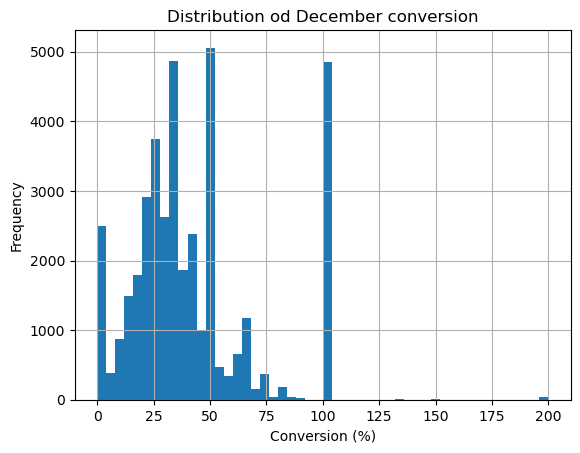

In [25]:
# Let's see the most converted cart events into purchases in December

fig, axis = plt.subplots()

(
    metrics_table[(np.isinf(metrics_table['december_conversion']) == False)
    & (np.isnan(metrics_table['december_conversion']) == False)]
    ['december_conversion']
    .mul(100)
    .hist(bins=50, ax=axis)
)

axis.set(
    title = 'Distribution od December conversion',
    xlabel = 'Conversion (%)',
    ylabel = 'Frequency'
);

> Most products convert at around 50%, but we also have a lot at 100% with a significantly low frequency till to 300%

In [28]:
# In order to make it meaningfull, let's look at over 99% of conversion

(
    metrics_table[(np.isinf(metrics_table["december_conversion"]) == False)
                 & (np.isnan(metrics_table["december_conversion"]) == False)
                 & (metrics_table["december_conversion"] > 0.99)]
    .sort_values("december_conversion", ascending=False)
    .head(20)
)

,product_id,product_identifier,november_volume,november_revenue,november_users,december_volume,december_revenue,december_users,volume_diff,revenue_diff,user_diff,november_cart,november_purchase,december_cart,december_purchase,november_conversion,december_conversion,volume_diff_pct
15906,9200683,9200683-hp computers.peripherals.keyboard,2,86.48,2,2,83.91,2,0,-2.57,0,2,2,1,2,1.0,2.0,0.0
29579,26403707,26403707-diamant appliances.kitchen.coffee_gri...,0,0.00,0,2,391.78,1,2,391.78,1,0,0,1,2,NaN,2.0,inf
26825,21410218,21410218-orient electronics.clocks,4,646.60,4,2,323.30,2,-2,-323.30,-2,10,4,1,2,0.4,2.0,-50.0
19892,13900871,13900871-lemark computers.desktop,0,0.00,0,2,134.77,2,2,134.77,2,0,0,1,2,NaN,2.0,inf
7640,4501204,4501204-electrolux appliances.kitchen.hob,0,0.00,0,2,823.66,1,2,823.66,1,2,0,1,2,0.0,2.0,inf
14090,7300445,7300445-kingston appliances.personal.massager,0,0.00,0,2,197.68,1,2,197.68,1,0,0,1,2,NaN,2.0,inf
10947,5801567,5801567-swat electronics.audio.subwoofer,0,0.00,0,2,77.22,2,2,77.22,2,1,0,1,2,0.0,2.0,inf
3861,2501051,2501051-gefest appliances.kitchen.oven,0,0.00,0,2,630.64,1,2,630.64,1,0,0,1,2,NaN,2.0,inf
2458,1701073,1701073-iiyama computers.peripherals.monitor,0,0.00,0,2,431.15,1,2,431.15,1,3,0,1,2,0.0,2.0,inf
31478,28705382,28705382-escan apparel.shoes.keds,0,0.00,0,2,169.38,2,2,169.38,2,0,0,1,2,NaN,2.0,inf


In [29]:
# Select a random product for observation
events[(events["product_id"] == 9200694)
& (events["event_time"].dt.month == 12)]

,event_time,event_type,product_id,brand,subcategory,category_id,category,user_id,user_session,product_identifier,price
4698592,2019-12-17 13:01:28+00:00,cart,9200694,NaN,apparel.scarf,2232732104343421549,apparel,513304382,ecb28e2c-525d-4adb-998e-fd589d66ca86,NaN,84.94
4698610,2019-12-17 13:01:38+00:00,purchase,9200694,NaN,apparel.scarf,2232732104343421549,apparel,513304382,ecb28e2c-525d-4adb-998e-fd589d66ca86,NaN,84.94
5124731,2019-12-20 04:04:58+00:00,purchase,9200694,NaN,apparel.scarf,2232732104343421549,apparel,513304382,d607a412-9e1c-4ab4-89be-b4dd3fe8def1,NaN,84.94
5192399,2019-12-20 10:56:30+00:00,purchase,9200694,NaN,apparel.scarf,2232732104343421549,apparel,513304382,935b176b-19ee-47f1-8332-1144e970c495,NaN,84.94


> There is a scarf that was bought three times by the same user on two different dates but with only one associated cart event. This could mean either a data error where we are missing two cart events or that we made incorrect assumptions about the data-generating process. When we said conversion should not be over 100%, we assumed a linear process where a user cannot make a purchase without putting an item into their cart. However, it is possible there is an “orders” page where a user could review their past orders and reorder products, while bypassing the cart screens.

> As it stands, we have no way of knowing whether these instances are valid, so to get our top performers, we can simply restrict our data to under 100% conversion.

In [32]:
# Best performers based on conversion rate

MIN_USERS = 5
MIN_PURCHASES = 10
CONVERSION_LOWER_LIMIT = 0.7

best_december_converters = (
    metrics_table[(np.isinf(metrics_table["december_conversion"]) == False)
             & (np.isnan(metrics_table["december_conversion"]) == False)
             & (metrics_table["december_conversion"]
   .between(CONVERSION_LOWER_LIMIT, 1))
             & (metrics_table["december_users"] > MIN_USERS)
             & (metrics_table["december_purchase"] > MIN_PURCHASES)]
    .sort_values("december_conversion", ascending=False)
    .merge(product_catalog.drop(columns=["product_identifier"]),
  on=["product_id"])
)

print(best_december_converters.shape)

(41, 22)


> This means there are 41 products in total that were bought by at least five different users, totaling a minimum of 10 sales, and converted over 70% of their cart events to purchase ones. 

In [33]:
# Their corresponding categories
best_december_converters["category"].value_counts()

category
electronics     6
appliances      6
kids            6
computers       5
furniture       5
apparel         4
construction    3
auto            3
sport           2
accessories     1
Name: count, dtype: int64

> When conversion is considered the key metric, electronics, appliances and kids items come up as the highest performers. 

In [35]:
# Looking their subcategories

best_december_converters.loc[best_december_converters["category"]
                             .isin(["electronics", "appliances", "kids"]), "subcategory"].value_counts()

subcategory
kids.carriage                             3
appliances.environment.air_conditioner    2
electronics.video.tv                      2
electronics.audio.acoustic                1
appliances.kitchen.hood                   1
kids.dolls                                1
kids.swing                                1
kids.skates                               1
appliances.kitchen.refrigerators          1
appliances.personal.massager              1
electronics.tablet                        1
appliances.kitchen.washer                 1
electronics.smartphone                    1
electronics.audio.headphone               1
Name: count, dtype: int64

In [20]:
# purchases_table.to_csv("purchases.csv", index=False)